<a href="https://colab.research.google.com/github/ibel123/OIBSIP/blob/main/DataScience-Task3-CarPricePrediction/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Price Prediction with Machine Learning

Oasis Infobyte SIP, Data Science Track, Task 3

This notebook builds a model that predicts the selling price of a used car based on details like its brand, age, mileage, fuel type, and transmission type.

We will follow these steps:
1. Load the dataset
2. Clean the data (handle missing values, duplicates, inconsistent text)
3. Engineer new features (car age, brand)
4. Explore the data (EDA)
5. Encode categorical columns into numbers
6. Check correlation between variables
7. Split the data into training and testing sets
8. Train two regression models
9. Evaluate both models
10. Look at feature importance


## Step 1: Import the libraries we need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


## Step 2: Load the dataset

You need to download a used car dataset from Kaggle first. Search for "Vehicle dataset from cardekho" or "Car Price Prediction dataset" on kaggle.com and download the CSV file.

Run the cell below and upload your CSV file when the upload button appears.

In [2]:
from google.colab import files

uploaded = files.upload()


Saving car data.csv to car data.csv


In [3]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
df.head(n=10)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [4]:
print("Column names in this dataset:")
print(list(df.columns))



Column names in this dataset:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


## Step 3: First look at the data

Before cleaning anything, we check the shape, the data types, and how many values are missing in each column.

In [5]:
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (301, 9)


In [6]:
print("Data types of each column:")
df.dtypes


Data types of each column:


,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [7]:
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [8]:
print("Number of exact duplicate rows:", df.duplicated().sum())


Number of exact duplicate rows: 2


## Step 4: Clean the data

Now we handle what we found above. We will:
1. Remove duplicate rows
2. Handle missing values
3. Fix inconsistent text in categorical columns, for example "Petrol" versus "petrol"


In [9]:
# Remove exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")


Removed 2 duplicate rows


In [10]:
# Drop rows that are missing the selling price, since that is what we are predicting
df = df.dropna(subset=["Selling_Price"])

# For other columns, fill missing numeric values with the median, and missing text values with the most common value
for column in df.columns:
    if df[column].dtype in ["int64", "float64"]:
        df[column] = df[column].fillna(df[column].median())
    else:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values remaining:")
df.isnull().sum()


Missing values remaining:


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [11]:
# Standardize text columns: lowercase everything and strip extra spaces
# This fixes cases like "Petrol" vs "petrol " being treated as two different categories
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

df[text_columns].head()


,Car_Name,Fuel_Type,Seller_Type,Transmission
0,ritz,petrol,dealer,manual
1,sx4,diesel,dealer,manual
2,ciaz,petrol,dealer,manual
3,wagon r,petrol,dealer,manual
4,swift,diesel,dealer,manual


If "Petrol" and "petrol" are treated as two different categories, the model wastes effort trying to learn two separate patterns for what is really the same thing. Standardizing text prevents this.

## Step 5: Feature engineering

Two of the most useful new features we can create are:
1. Car age, calculated from the year the car was made
2. Brand, extracted from the car name (the name column usually contains the full model name, we only want the first word, which is the brand)

In [12]:
current_year = 2026

df["car_age"] = current_year - df["Year"]

df[["Year", "car_age"]].head()


,Year,car_age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [13]:
# Extract the brand as the first word of the name column
df["brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name", "brand"]].head()


,Car_Name,brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


In [14]:
print("Number of unique brands found:", df["brand"].nunique())
df["brand"].value_counts().head(10)


Number of unique brands found: 44


,count
brand,
city,26
bajaj,25
corolla,17
royal,17
honda,17
hero,15
verna,14
etios,11
fortuner,10


## Step 6: Explore the cleaned data

Now that the data is cleaner, we look at how selling price relates to a few key variables.

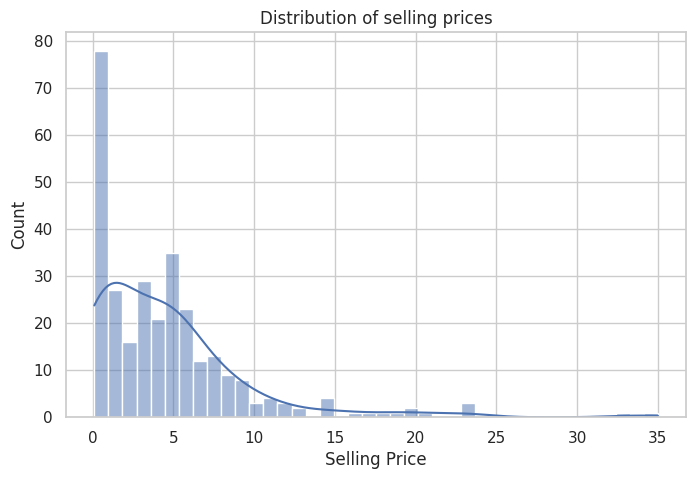

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], bins=40, kde=True)
plt.title("Distribution of selling prices")
plt.xlabel("Selling Price")
plt.show()


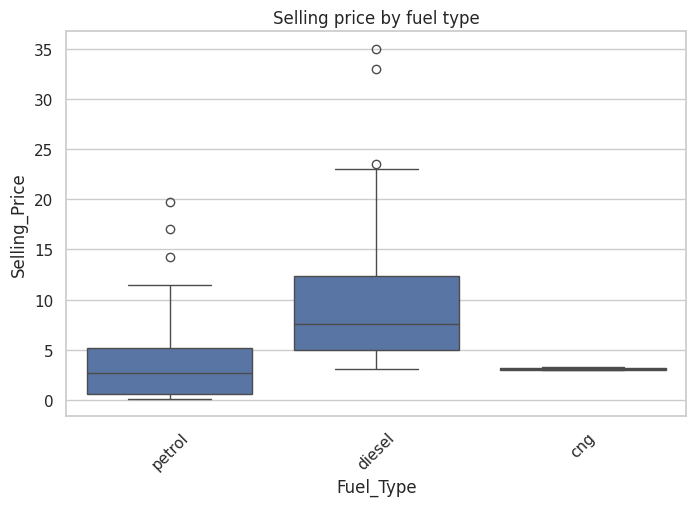

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Selling price by fuel type")
plt.xticks(rotation=45)
plt.show()


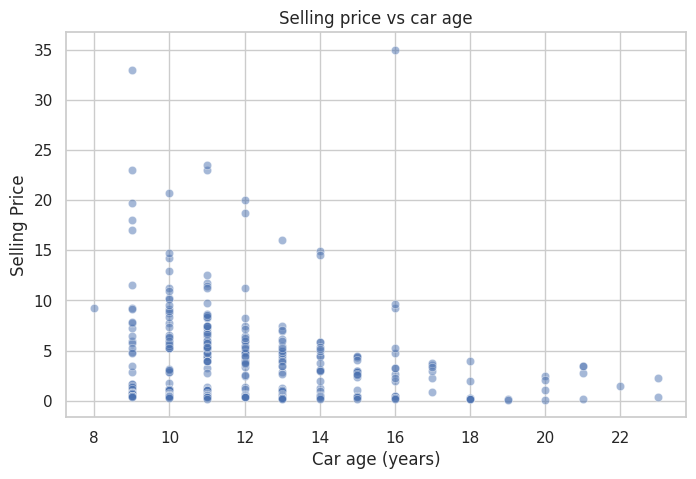

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="Selling_Price", alpha=0.5)
plt.title("Selling price vs car age")
plt.xlabel("Car age (years)")
plt.ylabel("Selling Price")
plt.show()


Selling prices are right skewed, meaning most cars sell for a moderate price but a smaller number of expensive cars pull the average up. Diesel and petrol cars make up most of the listings. Selling price tends to fall as car age increases, which matches common sense: older cars are usually worth less.

## Step 7: Encode categorical columns

Machine learning models need numbers, not text. We convert text categories like fuel type and transmission into numeric columns using one hot encoding, which creates a separate 0 or 1 column for each category.

To keep the model manageable, we group any brand that appears fewer than 10 times into a single "other" category before encoding, since a very large number of rare brands can make the model harder to train well.

In [18]:
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index

df["brand"] = df["brand"].apply(lambda x: "other" if x in rare_brands else x)

print("Number of brand categories after grouping rare ones:", df["brand"].nunique())


Number of brand categories after grouping rare ones: 11


In [19]:
categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission", "Owner", "brand"]

df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df_encoded.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,car_age,Fuel_Type_diesel,Fuel_Type_petrol,Seller_Type_individual,Transmission_manual,...,brand_brio,brand_city,brand_corolla,brand_etios,brand_fortuner,brand_hero,brand_honda,brand_other,brand_royal,brand_verna
0,ritz,2014,3.35,5.59,27000,12,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
1,sx4,2013,4.75,9.54,43000,13,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,ciaz,2017,7.25,9.85,6900,9,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
3,wagon r,2011,2.85,4.15,5200,15,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
4,swift,2014,4.60,6.87,42450,12,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False


## Step 8: Correlation heatmap

We check how strongly the numeric features relate to selling price and to each other.

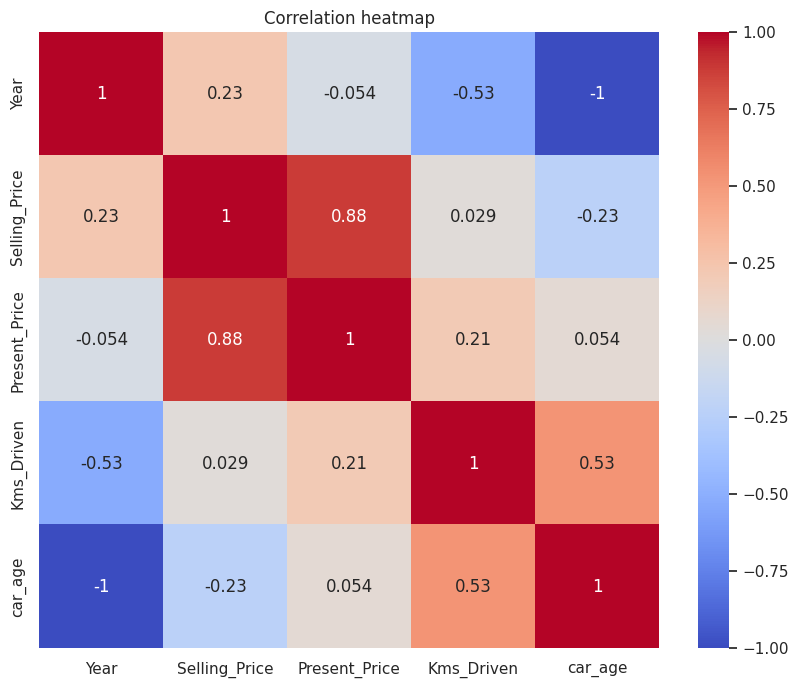

In [20]:
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


## Step 9: Split the data into training and testing sets

We drop columns that are not useful as model inputs, for example the raw car name and year, since we already captured their useful information in `brand` and `car_age`.

In [21]:
columns_to_drop = ["Car_Name", "Year", "Selling_Price"]


X = df_encoded.drop(columns=columns_to_drop)
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of input features:", X_train.shape[1])


Training samples: 239
Testing samples: 60
Number of input features: 19


## Step 10: Train two regression models

We train:
1. Linear Regression, our baseline
2. Random Forest Regressor

In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_reg_preds = lin_reg.predict(X_test)


In [23]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

rf_preds = rf_reg.predict(X_test)


## Step 11: Evaluate both models

We compare both models using three measures. MAE tells us the average size of the mistake in the same units as price. RMSE is similar but punishes big mistakes more heavily. R squared tells us how much of the variation in selling price the model explains, closer to 1 is better.

In [24]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R2:   {r2:.3f}")
    print()

evaluate("Linear Regression", y_test, lin_reg_preds)
evaluate("Random Forest Regressor", y_test, rf_preds)


Linear Regression
  MAE:  1.37
  RMSE: 2.33
  R2:   0.790

Random Forest Regressor
  MAE:  1.47
  RMSE: 3.56
  R2:   0.509



Based on these numbers, Linear Regression performed better on this dataset, since it produced a lower RMSE and a higher R squared than Random Forest.

## Step 12: Feature importance for the best model

We look at which features the Linear Regression model relied on most heavily to make its predictions.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_scaled, y)

coefficients_scaled = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg_scaled.coef_
})



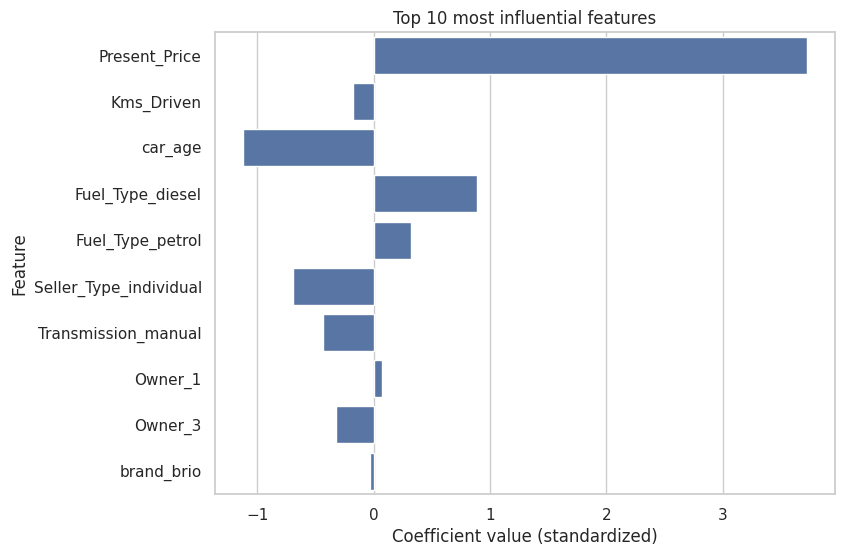

In [26]:
plt.figure(figsize=(8, 6))
top_features = coefficients_scaled.head(10)
sns.barplot(data=top_features, x="Coefficient", y="Feature")
plt.title("Top 10 most influential features")
plt.xlabel("Coefficient value (standardized)")
plt.show()



`Present_price`, `Car_age`, and `Fuel_Type` rank among the most important features.

## Conclusion



After cleaning the dataset and engineering car age and brand as new features, Linear Regression outperformed Random Forest on this dataset, with a lower RMSE and a higher R squared score. This is likely explained by two factors. First, the dataset includes present price, the car's original showroom price, which has a strong and fairly direct straight line relationship with selling price, exactly the kind of pattern Linear Regression is built to capture well. Second, with only 301 rows, Random Forest had less data available to learn reliable patterns from, which can make it perform less consistently than a simpler model. This shows that a more flexible model like Random Forest is not automatically better, the right model depends on the size and structure of the data
